In [1]:
%pip install azure-identity azure-storage-blob pandas
%pip install scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import json
from io import BytesIO
from azure.identity import DefaultAzureCredential
from azure.storage.blob import BlobServiceClient

# --- 1. ENTERPRISE CONFIGURATION ---
# We use the raw URL instead of a secret connection string!
ACCOUNT_URL = "https://rawtradingdata26.blob.core.windows.net"
CONTAINER_NAME = "raw-market-data"
MARKET_BLOB_NAME = "market_data_20260328.csv" 
MACRO_BLOB_NAME = "macro_data_20260328.json"  

# Authenticate securely using the workspace's Managed Identity
print("Authenticating with Azure Managed Identity...")
credential = DefaultAzureCredential()
blob_service_client = BlobServiceClient(account_url=ACCOUNT_URL, credential=credential)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# --- 2. LOAD MARKET DATA (CSV) ---
print("Downloading Market Data securely...")
market_blob_client = container_client.get_blob_client(MARKET_BLOB_NAME)
market_download = market_blob_client.download_blob().readall()

df_market = pd.read_csv(BytesIO(market_download), header=[0, 1], index_col=0, parse_dates=True)
print(f"Market Data Loaded: {df_market.shape}")

# --- 3. LOAD MACRO DATA (JSON) ---
print("Downloading Macro Data securely...")
macro_blob_client = container_client.get_blob_client(MACRO_BLOB_NAME)
macro_download = macro_blob_client.download_blob().readall()

macro_json = json.loads(macro_download)
df_macro = pd.DataFrame(macro_json['observations'])

df_macro['date'] = pd.to_datetime(df_macro['date'])
df_macro['value'] = pd.to_numeric(df_macro['value'], errors='coerce')
df_macro = df_macro[['date', 'value']].rename(columns={'value': 'CPI'}).set_index('date')
print(f"Macro Data Loaded: {df_macro.shape}")

# Verify the data
display(df_market.head())

Authenticating with Azure Managed Identity...
Market Data Loaded: (251, 15)
Macro Data Loaded: (950, 1)


Price            Close                               High              \
Ticker             SPY         XLK        XLU         SPY         XLK   
Date                                                                    
2025-03-28  549.362366  102.731216  38.176247  559.852162  105.160363   
2025-03-31  553.050049  102.780983  38.602165  554.355096  103.014939   
2025-04-01  554.612122  103.532631  38.700085  556.559826  103.622227   
2025-04-02  558.122009  104.299210  38.881218  560.989106  105.160362   
2025-04-03  530.617188   97.181000  38.636436  541.759415   99.903841   

Price                         Low                               Open  \
Ticker            XLU         SPY         XLK        XLU         SPY   
Date                                                                   
2025-03-28  38.416132  548.779086  102.382766  38.058748  559.120559   
2025-03-31  38.758826  540.671928   99.918765  38.225202  543.598402   
2025-04-01  38.812682  547.404766  101.536540  38.328015  551.132057   
2025-04-02  38.969340  548.522036  101.974592  38.474878  548.759307   
2025-04-03  39.267975  530.617188   97.101361  38.587481  538.931844   

Price                                 Volume                      
Ticker             XLK        XLU        SPY       XLK       XLU  
Date                                                              
2025-03-28  104.737257  38.127287   71662700  10667600  19078600  
2025-03-31  100.939210  38.234992   95328200  14219000  21470000  
2025-04-01  102.372810  38.577694   54609600   9480200  18084800  
2025-04-02  102.054238  38.670705   76014500   9292000  12951200  
2025-04-03   99.301535  38.832263  125986000  19451400  38650200

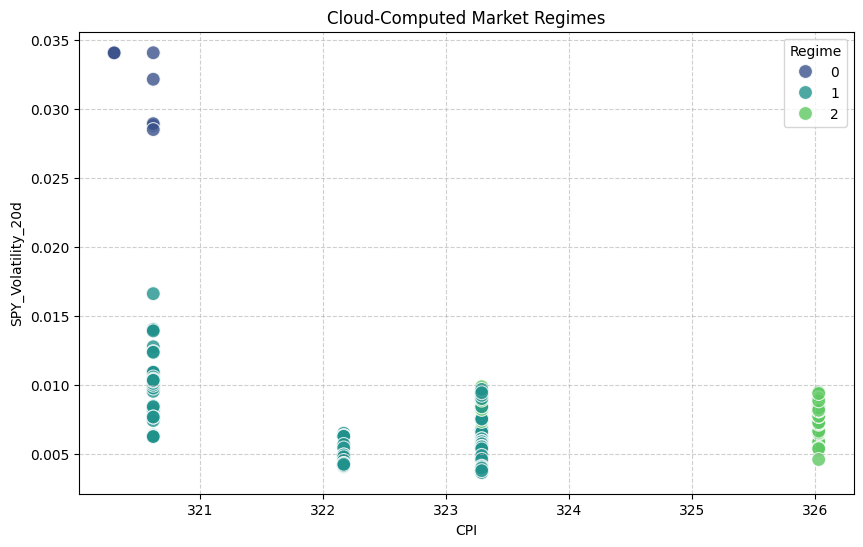


--- Cloud Cluster Averages ---


,SPY_Daily_Return,SPY_Volatility_20d,CPI
Regime,,,
0,0.002390,0.031822,320.500750
1,0.002507,0.007372,322.382429
2,-0.002149,0.007468,325.757000


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CLEAN & ALIGN ---
df_market.columns = [f"{col[0]}_{col[1]}" for col in df_market.columns.values]
df_merged = df_market.join(df_macro, how='left')
df_merged['CPI'] = df_merged['CPI'].ffill()

# --- 2. FEATURE ENGINEERING ---
df_merged['SPY_Daily_Return'] = df_merged['Close_SPY'].pct_change()
df_merged['SPY_Volatility_20d'] = df_merged['SPY_Daily_Return'].rolling(window=20).std()
df_cleaned = df_merged.dropna().copy()

# --- 3. SCALING & CLUSTERING ---
features = ['SPY_Daily_Return', 'SPY_Volatility_20d', 'CPI']
X = df_cleaned[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cleaned['Regime'] = kmeans.fit_predict(X_scaled).astype(str)

# --- 4. VISUALIZE ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='CPI', y='SPY_Volatility_20d', hue='Regime', palette='viridis', s=100, alpha=0.8)
plt.title('Cloud-Computed Market Regimes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- Cloud Cluster Averages ---")
display(df_cleaned.groupby('Regime')[features].mean())